# Supervised Learning: Regression

Generate a synthetic dataset for regression analysis. This step will import the necessary function, generate the dataset with specified parameters, and print the shapes to verify.



In [ ]:
from sklearn.datasets import make_regression

X_reg, y_reg = make_regression(n_samples=1000, n_features=10, n_informative=8, noise=50, random_state=42)

print(f"Shape of X_reg: {X_reg.shape}")
print(f"Shape of y_reg: {y_reg.shape}")

Shape of X_reg: (1000, 10)
Shape of y_reg: (1000,)


Split the generated dataset into training and testing sets.

#### Instructions:
1. Import `train_test_split` from `sklearn.model_selection`.
2. Split the `X_reg` and `y_reg` datasets into training and testing sets using a `test_size` of `0.2` and `random_state` of `42`. Store them in `X_train_reg`, `X_test_reg`, `y_train_reg`, and `y_test_reg` respectively.
3. Print the shapes of the training and testing sets to verify the split.

Implement the code to split the generated dataset into training and testing sets, then print their shapes to confirm the split.



In [ ]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print(f"Shape of X_train_reg: {X_train_reg.shape}")
print(f"Shape of X_test_reg: {X_test_reg.shape}")
print(f"Shape of y_train_reg: {y_train_reg.shape}")
print(f"Shape of y_test_reg: {y_test_reg.shape}")

Shape of X_train_reg: (800, 10)
Shape of X_test_reg: (200, 10)
Shape of y_train_reg: (800,)
Shape of y_test_reg: (200,)


Train multiple regression models and make predictions.

#### Instructions:
1. Import the following regression models from `sklearn`:
    - `LinearRegression` from `sklearn.linear_model`
    - `KNeighborsRegressor` from `sklearn.neighbors`
    - `DecisionTreeRegressor` from `sklearn.tree`
    - `RandomForestRegressor` from `sklearn.ensemble`
    - `GradientBoostingRegressor` from `sklearn.ensemble`
    - `SVR` from `sklearn.svm`
2. Initialize each model with `random_state=42` where applicable (for `DecisionTreeRegressor`, `RandomForestRegressor`, `GradientBoostingRegressor`). For `KNeighborsRegressor`, use `n_neighbors=5`.
3. Train each model using `X_train_reg` and `y_train_reg`.
4. Make predictions on `X_test_reg` for each model and store the predictions in variables such as `y_pred_reg_lr`, `y_pred_reg_knn`, etc.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# 1. Initialize models
lr_model = LinearRegression()
knn_model = KNeighborsRegressor(n_neighbors=5)
dt_model = DecisionTreeRegressor(random_state=42)
rf_model = RandomForestRegressor(random_state=42)
gbr_model = GradientBoostingRegressor(random_state=42)
svr_model = SVR()

# 2. Train models
lr_model.fit(X_train_reg, y_train_reg)
knn_model.fit(X_train_reg, y_train_reg)
dt_model.fit(X_train_reg, y_train_reg)
rf_model.fit(X_train_reg, y_train_reg)
gbr_model.fit(X_train_reg, y_train_reg)
svr_model.fit(X_train_reg, y_train_reg)

# 3. Make predictions
y_pred_reg_lr = lr_model.predict(X_test_reg)
y_pred_reg_knn = knn_model.predict(X_test_reg)
y_pred_reg_dt = dt_model.predict(X_test_reg)
y_pred_reg_rf = rf_model.predict(X_test_reg)
y_pred_reg_gbr = gbr_model.predict(X_test_reg)
y_pred_reg_svr = svr_model.predict(X_test_reg)

print("Regression models trained and predictions made.")

Regression models trained and predictions made.


Create the subplots and plot the predicted vs. actual values for each of the six regression models.



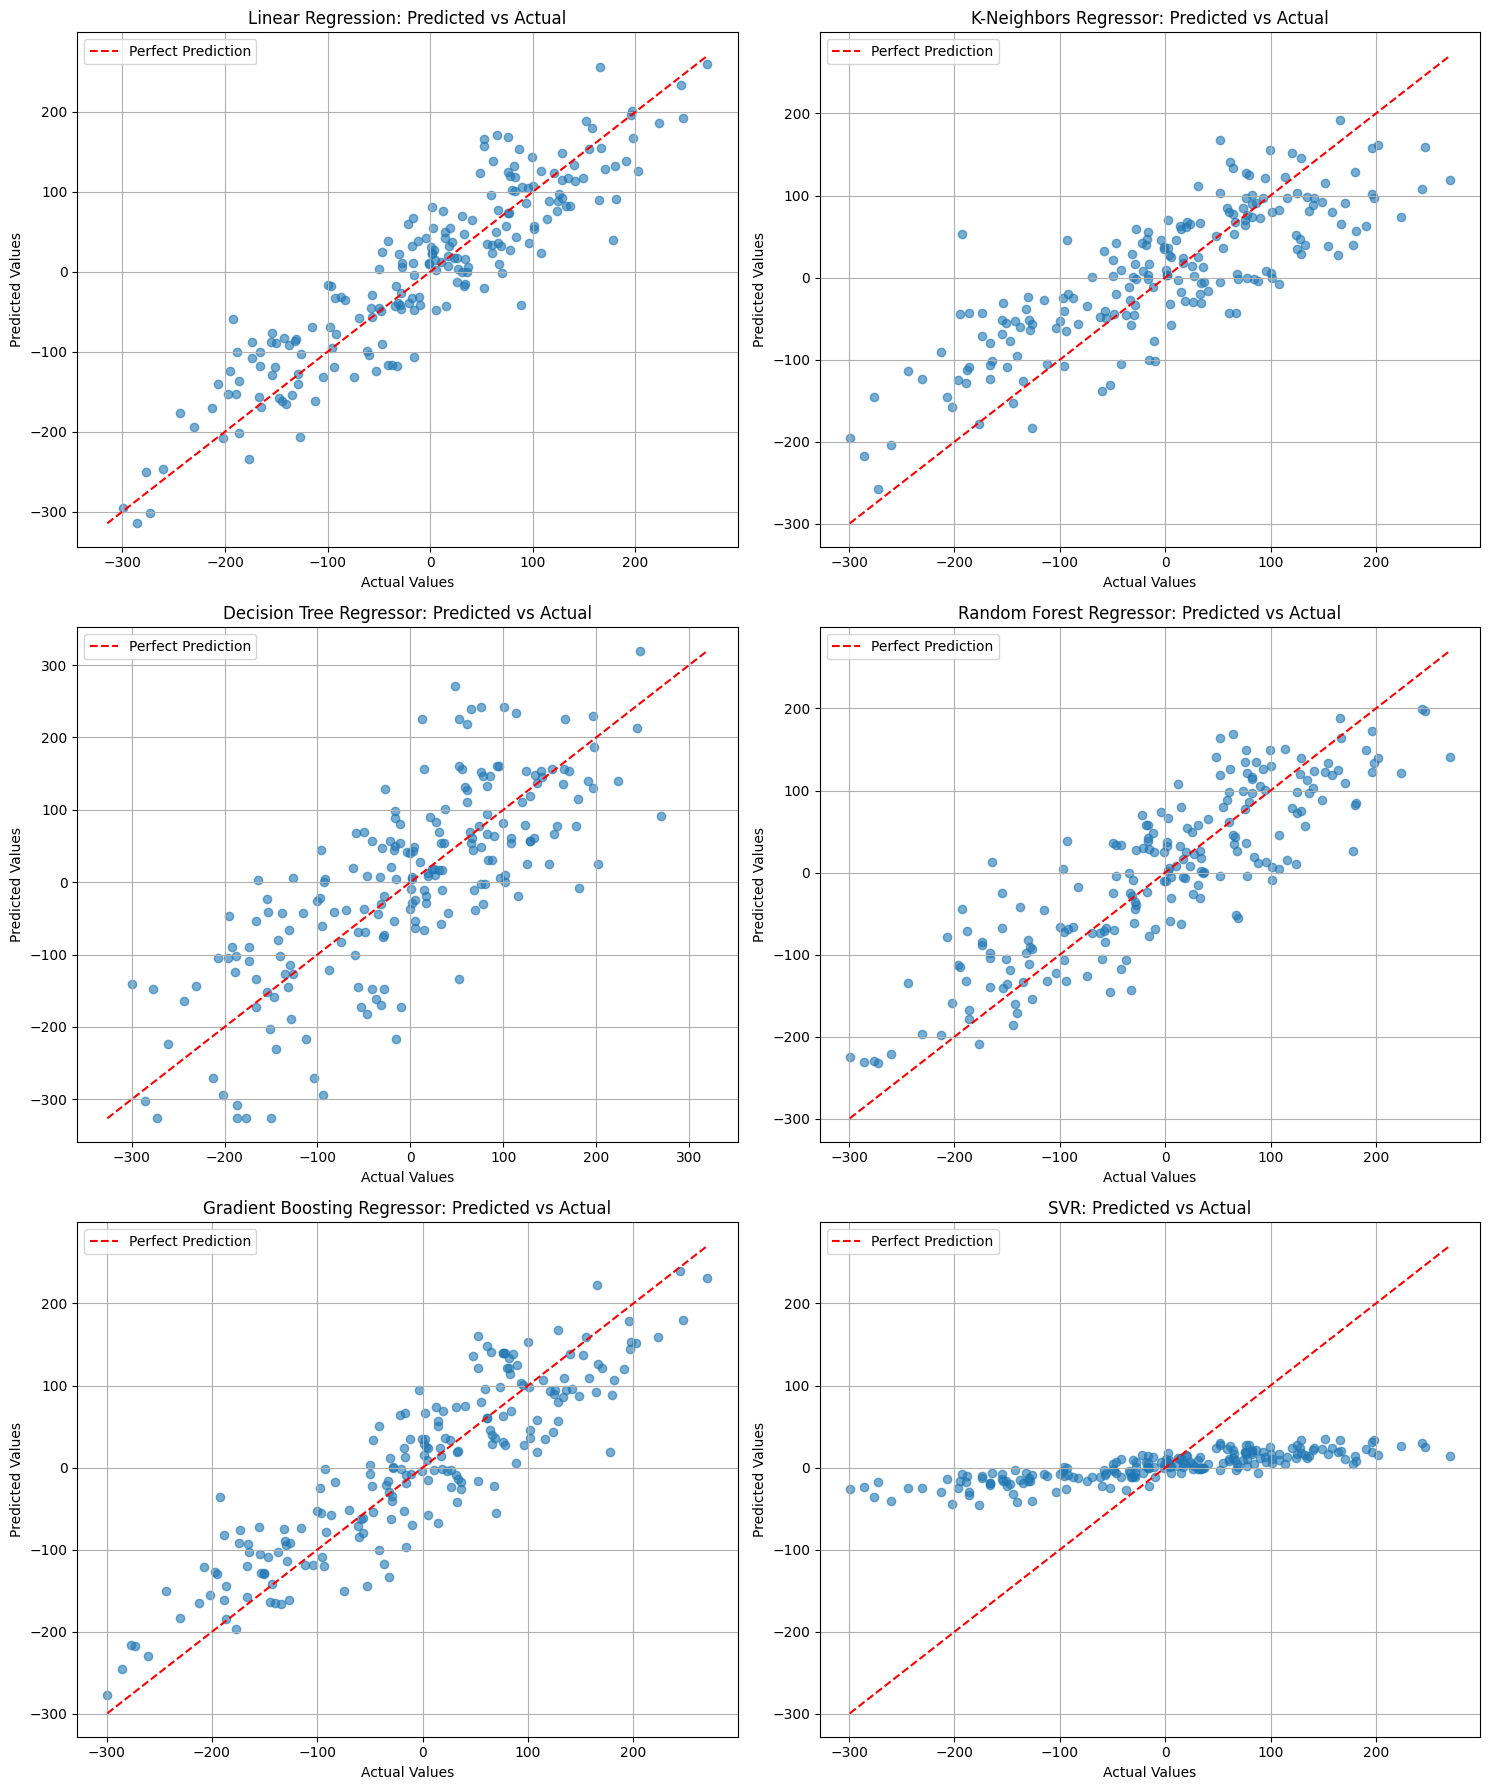

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare model names and predictions
model_names = [
    "Linear Regression",
    "K-Neighbors Regressor",
    "Decision Tree Regressor",
    "Random Forest Regressor",
    "Gradient Boosting Regressor",
    "SVR"
]

predictions = [
    y_pred_reg_lr,
    y_pred_reg_knn,
    y_pred_reg_dt,
    y_pred_reg_rf,
    y_pred_reg_gbr,
    y_pred_reg_svr
]

# Create a 3x2 subplot grid
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, (name, y_pred) in enumerate(zip(model_names, predictions)):
    ax = axes[i]

    # Scatter plot of actual vs predicted values
    ax.scatter(y_test_reg, y_pred, alpha=0.6)

    # Add a perfect prediction line (y=x)
    min_val = min(y_test_reg.min(), y_pred.min())
    max_val = max(y_test_reg.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

    # Set title and labels
    ax.set_title(f'{name}: Predicted vs Actual')
    ax.set_xlabel('Actual Values')
    ax.set_ylabel('Predicted Values')
    ax.legend()
    ax.grid(True)

# Adjust layout to prevent overlapping titles and labels
plt.tight_layout()
plt.show()


Calculate and display the MSE and R-squared for each model, and then identify the best-performing one.



In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Initialize lists to store metrics
model_names = [
    "Linear Regression",
    "K-Neighbors Regressor",
    "Decision Tree Regressor",
    "Random Forest Regressor",
    "Gradient Boosting Regressor",
    "SVR"
]

predictions = [
    y_pred_reg_lr,
    y_pred_reg_knn,
    y_pred_reg_dt,
    y_pred_reg_rf,
    y_pred_reg_gbr,
    y_pred_reg_svr
]

mse_scores = []
r2_scores = []

# Calculate metrics for each model
for name, y_pred in zip(model_names, predictions):
    mse = mean_squared_error(y_test_reg, y_pred)
    r2 = r2_score(y_test_reg, y_pred)
    mse_scores.append(mse)
    r2_scores.append(r2)

# Store metrics in a DataFrame
metrics_df = pd.DataFrame({
    'Model': model_names,
    'MSE': mse_scores,
    'R-squared': r2_scores
})

print("Regression Model Performance:")
print(metrics_df)
print("\n")

# Identify the best-performing model
best_model_mse = metrics_df.loc[metrics_df['MSE'].idxmin()]
best_model_r2 = metrics_df.loc[metrics_df['R-squared'].idxmax()]

print("Best performing model (lowest MSE):")
print(best_model_mse)
print("\n")

print("Best performing model (highest R-squared):")
print(best_model_r2)


Regression Model Performance:
                         Model           MSE  R-squared
0            Linear Regression   2342.287346   0.834463
1        K-Neighbors Regressor   4834.089241   0.658360
2      Decision Tree Regressor   7627.486722   0.460942
3      Random Forest Regressor   3574.331535   0.747391
4  Gradient Boosting Regressor   2786.857390   0.803044
5                          SVR  11039.186025   0.219826


Best performing model (lowest MSE):
Model        Linear Regression
MSE                2342.287346
R-squared             0.834463
Name: 0, dtype: object


Best performing model (highest R-squared):
Model        Linear Regression
MSE                2342.287346
R-squared             0.834463
Name: 0, dtype: object


### Data Analysis Key Findings
*   A synthetic dataset was successfully generated with 1000 samples and 10 features (`X_reg` shape: (1000, 10), `y_reg` shape: (1000,)).
*   The dataset was split into training and testing sets, resulting in 800 samples for training and 200 samples for testing.
*   Six different regression models (Linear Regression, K-Neighbors Regressor, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor, and SVR) were trained and used to make predictions.
*   The performance metrics (MSE and R-squared) for each model are as follows:
    *   **Linear Regression**: MSE = 2342.29, R-squared = 0.834
    *   **Gradient Boosting Regressor**: MSE = 2786.86, R-squared = 0.803
    *   **Random Forest Regressor**: MSE = 3574.33, R-squared = 0.747
    *   **K-Neighbors Regressor**: MSE = 4834.09, R-squared = 0.658
    *   **Decision Tree Regressor**: MSE = 7627.49, R-squared = 0.461
    *   **SVR**: MSE = 11039.19, R-squared = 0.220
*   Linear Regression emerged as the best-performing model, showing the lowest MSE (2342.29) and the highest R-squared (0.834), indicating a strong fit to the data.

Further investigation could involve hyperparameter tuning for models like Random Forest Regressor and Gradient Boosting Regressor, as they also showed good performance, to see if their metrics can approach or surpass Linear Regression.


## Supervised Learning: Classification

Generate a synthetic dataset for classification analysis. This step will import the necessary function, generate the dataset with specified parameters, and print the shapes to verify.

In [ ]:
from sklearn.datasets import make_classification

X_clf, y_clf = make_classification(n_samples=1000, n_features=10, n_informative=5, n_redundant=0, n_classes=2, random_state=42)

print(f"Shape of X_clf: {X_clf.shape}")
print(f"Shape of y_clf: {y_clf.shape}")

Shape of X_clf: (1000, 10)
Shape of y_clf: (1000,)


Split the generated dataset into training and testing sets for classification.

In [ ]:
from sklearn.model_selection import train_test_split

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

print(f"Shape of X_train_clf: {X_train_clf.shape}")
print(f"Shape of X_test_clf: {X_test_clf.shape}")
print(f"Shape of y_train_clf: {y_train_clf.shape}")
print(f"Shape of y_test_clf: {y_test_clf.shape}")

Shape of X_train_clf: (800, 10)
Shape of X_test_clf: (200, 10)
Shape of y_train_clf: (800,)
Shape of y_test_clf: (200,)


Train multiple classification models and make predictions.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# 1. Initialize models
nb_model = GaussianNB()
lr_clf_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' for small datasets
svc_model = SVC(random_state=42, probability=True) # probability=True to enable .predict_proba
dt_clf_model = DecisionTreeClassifier(random_state=42)

# 2. Train models
nb_model.fit(X_train_clf, y_train_clf)
lr_clf_model.fit(X_train_clf, y_train_clf)
svc_model.fit(X_train_clf, y_train_clf)
dt_clf_model.fit(X_train_clf, y_train_clf)

# 3. Make predictions
y_pred_clf_nb = nb_model.predict(X_test_clf)
y_pred_clf_lr = lr_clf_model.predict(X_test_clf)
y_pred_clf_svc = svc_model.predict(X_test_clf)
y_pred_clf_dt = dt_clf_model.predict(X_test_clf)

print("Classification models trained and predictions made.")

Classification models trained and predictions made.


Evaluate the performance of each classification model using various metrics.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd

# Initialize lists to store metrics
model_names_clf = [
    "Naive Bayes",
    "Logistic Regression",
    "Support Vector Classifier",
    "Decision Tree Classifier"
]

predictions_clf = [
    y_pred_clf_nb,
    y_pred_clf_lr,
    y_pred_clf_svc,
    y_pred_clf_dt
]

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
roc_auc_scores = []

# Re-initialize models list to map to predictions and probabilities correctly
models = [nb_model, lr_clf_model, svc_model, dt_clf_model]

# Calculate metrics for each model
for i, (name, y_pred) in enumerate(zip(model_names_clf, predictions_clf)):
    accuracy = accuracy_score(y_test_clf, y_pred)
    precision = precision_score(y_test_clf, y_pred)
    recall = recall_score(y_test_clf, y_pred)
    f1 = f1_score(y_test_clf, y_pred)

    # ROC AUC requires probability estimates
    if hasattr(models[i], 'predict_proba'):
        y_pred_proba = models[i].predict_proba(X_test_clf)[:, 1]
        roc_auc = roc_auc_score(y_test_clf, y_pred_proba)
    else:
        roc_auc = None # If model does not support predict_proba

    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    roc_auc_scores.append(roc_auc)

# Store metrics in a DataFrame
metrics_clf_df = pd.DataFrame({
    'Model': model_names_clf,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1-Score': f1_scores,
    'ROC AUC': roc_auc_scores
})

print("Classification Model Performance:")
print(metrics_clf_df)
print("\n")

# Identify the best-performing model based on F1-Score (common for classification)
best_model_f1 = metrics_clf_df.loc[metrics_clf_df['F1-Score'].idxmax()]

print("Best performing classification model (highest F1-Score):")
print(best_model_f1)

Classification Model Performance:
                       Model  Accuracy  Precision    Recall  F1-Score  \
0                Naive Bayes     0.775   0.774194  0.750000  0.761905   
1        Logistic Regression     0.770   0.740385  0.802083  0.770000   
2  Support Vector Classifier     0.905   0.873786  0.937500  0.904523   
3   Decision Tree Classifier     0.875   0.844660  0.906250  0.874372   

    ROC AUC  
0  0.847556  
1  0.820012  
2  0.945112  
3  0.876202  


Best performing classification model (highest F1-Score):
Model        Support Vector Classifier
Accuracy                         0.905
Precision                     0.873786
Recall                          0.9375
F1-Score                      0.904523
ROC AUC                       0.945112
Name: 2, dtype: object


### Classification Data Analysis Key Findings
*   A synthetic classification dataset was generated with 1000 samples and 10 features, with 2 target classes (`X_clf` shape: (1000, 10), `y_clf` shape: (1000,)).
*   The dataset was split into training (800 samples) and testing (200 samples) sets.
*   Four different classification models (Naive Bayes, Logistic Regression, Support Vector Classifier, and Decision Tree Classifier) were trained and used to make predictions.
*   The performance metrics (Accuracy, Precision, Recall, F1-Score, and ROC AUC) were calculated for each model.